## EJERCICIO ENUNCIADO

Usaremos el dataset de madrid idealista:

https://www.kaggle.com/datasets/kanchana1990/madrid-idealista-property-listings


4 columnas numéricas

* price
* bedrooms
* bathrooms
* m2
* address (quitarle lo de ", Madrid" con numpy)

En cada apartado hacer visualizaciones con matplotlib o seaborn.

* 25 %:

* Carga de datos: cargarlo con np.genfromtext usar encoding="utf-8"
* Media, mediana
* Máximo y mínimo
* histograma y curva de densidad

* 25 %

* Cuartiles: Q1 (25), Q2 (50), Q3 (75)
* IQR
* Filtrar 20 % más caro, y el 20 % más barato
* Opcional: filtrar los barrios 20 % más baratos
* Moda: calcular moda también de address
* Opcional: Moda de los barrios más baratos y más caros
* Dispersión: varianza y desviación estándar

25 % 

* Filtro de outliers: tukey, z-score, marcar en un gráfico los límites de outliers: rojo y azul.
* Correlación: calcular la matriz y pintarla con matplotlib/seaborn
* Estandarización

25 % 

* Asimetría y curtosis
* Transformar distribuciones e interpretar resultados
* Contraste de hipótesis:
    * Que las casas de X barrio son más baratas de las de Y barrio
    * Que las casas de >= 3 baños son más caras que las casas de 1-2 baños


Entrega: 27/12


Datasets opcionales, alternativas para futuros módulos:

* https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
* https://www.kaggle.com/datasets/desalegngeb/students-exam-scores
* https://www.kaggle.com/datasets/ziya07/music-education-performance-data

Fuentes datos:

* https://www.kaggle.com/datasets
* https://datos.gob.es/es/catalogo?res_format_label=CSV
* https://datasetsearch.research.google.com/
* seaborn.load_dataset('')
* https://github.com/mwaskom/seaborn-data

* Opcional
* MySQL Community Server + MySQL Workbench

Columnas disponibles en el DataFrame: Index(['price', 'bathrooms', 'bedrooms', 'm2', 'address'], dtype='object')
Media:
price        1.290575e+06
bedrooms     3.474317e+00
bathrooms    2.900546e+00
m2           2.172383e+02
dtype: float64

Mediana:
price        990000.0
bedrooms          3.0
bathrooms         3.0
m2              158.0
dtype: float64

Máximo y Mínimo:
       price  bedrooms  bathrooms    m2
max  8900000        12         12  1768
min   122000         0          1    14


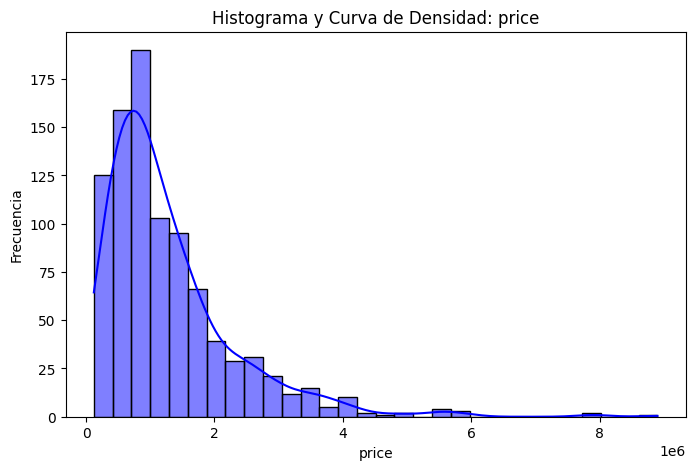

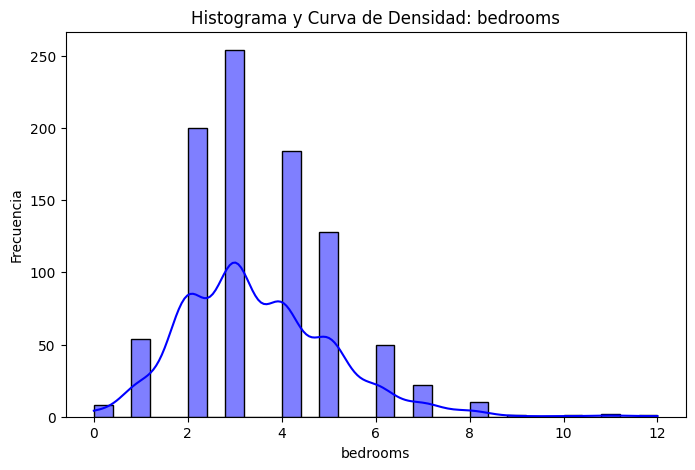

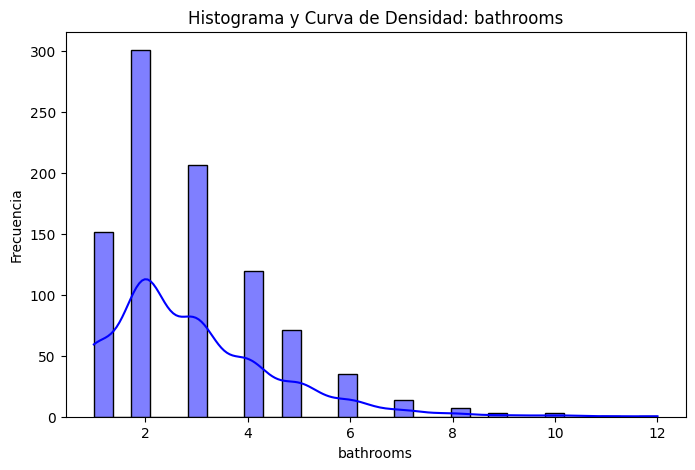

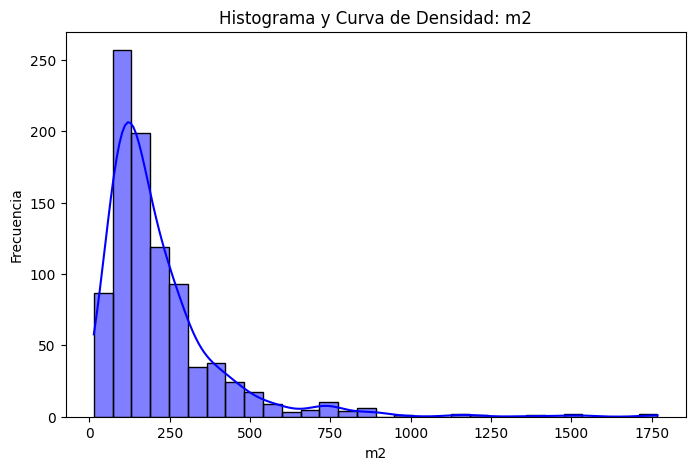


Cuartiles:
          price  bedrooms  bathrooms     m2
0.25   625000.0       2.0        2.0  104.0
0.50   990000.0       3.0        3.0  158.0
0.75  1650000.0       4.0        4.0  264.0

IQR:
price        1025000.0
bedrooms           2.0
bathrooms          2.0
m2               160.0
dtype: float64

Moda de address:
0    Barrio de Salamanca
Name: address, dtype: object

Varianza y Desviación Estándar:
price        1.074623e+12
bedrooms     2.542830e+00
bathrooms    2.645459e+00
m2           3.676646e+04
dtype: float64
price        1.036640e+06
bedrooms     1.594625e+00
bathrooms    1.626487e+00
m2           1.917458e+02
dtype: float64


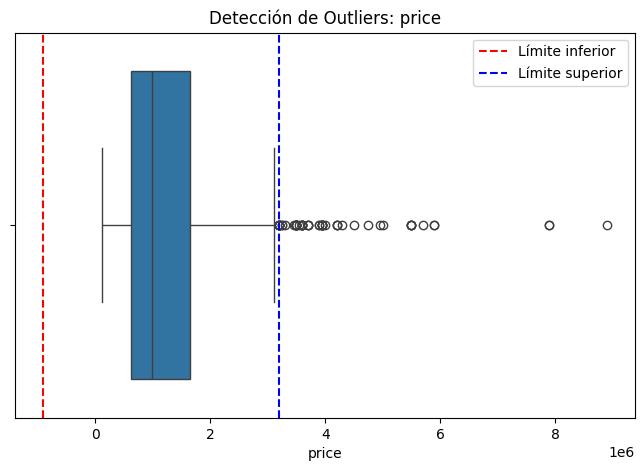

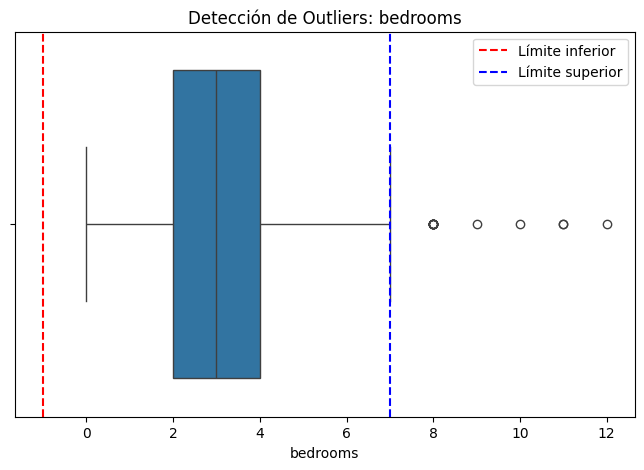

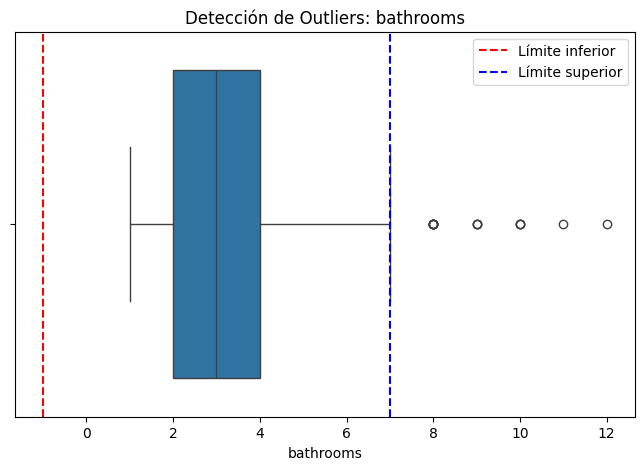

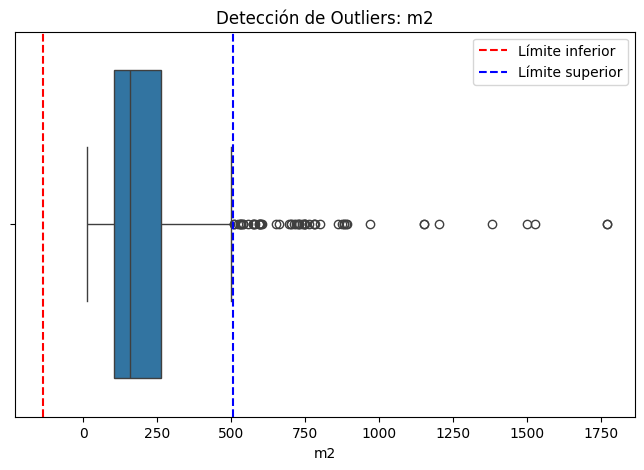

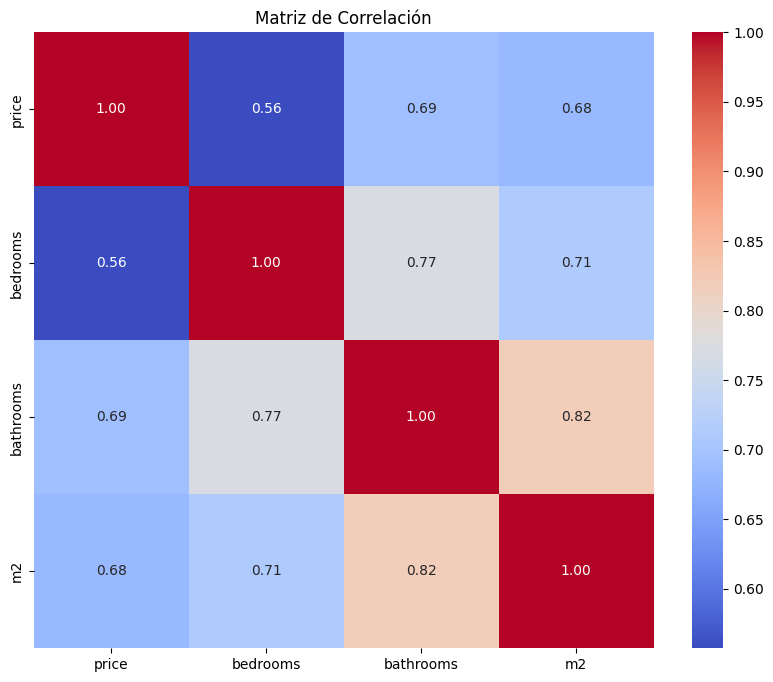


Datos estandarizados (Primeras filas):
      price  bedrooms  bathrooms        m2
0  0.607178 -0.297447   0.061146 -0.178561
1  0.679527 -0.297447   0.061146 -0.246359
2  0.009092  0.329659   0.061146  0.275165
3  0.346721 -0.297447   0.061146  0.160430
4  0.289565 -0.297447   0.061146 -0.527982
Asimetría (price): 2.299673447902698
Curtosis (price): 8.547211919938682
Asimetría (bedrooms): 0.8842091486712003
Curtosis (bedrooms): 1.9002632477464054
Asimetría (bathrooms): 1.406223480498869
Curtosis (bathrooms): 3.038919834628685
Asimetría (m2): 3.358506945156488
Curtosis (m2): 17.229111152834456


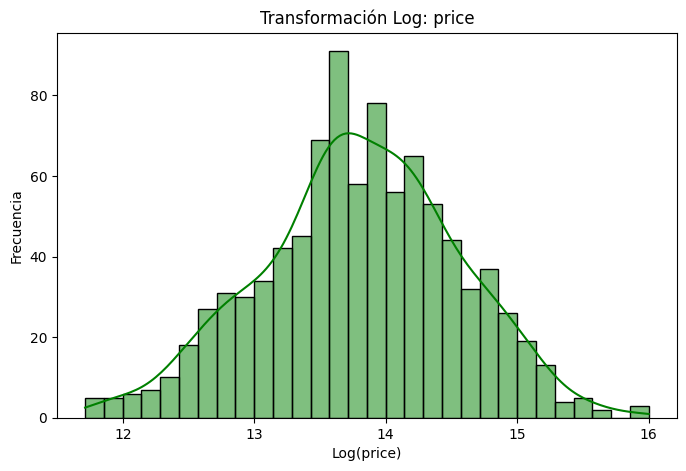

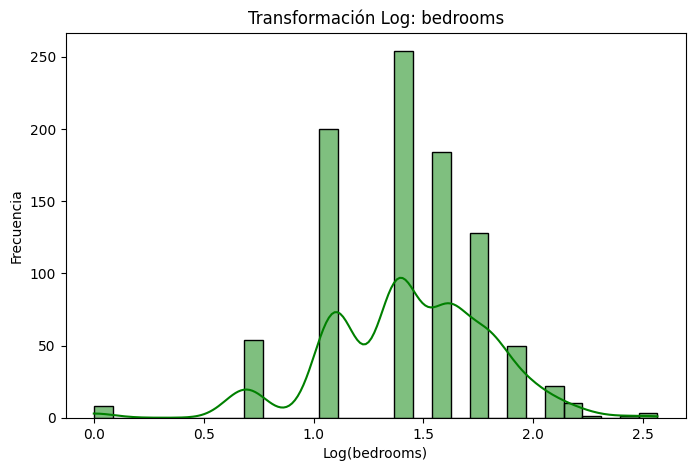

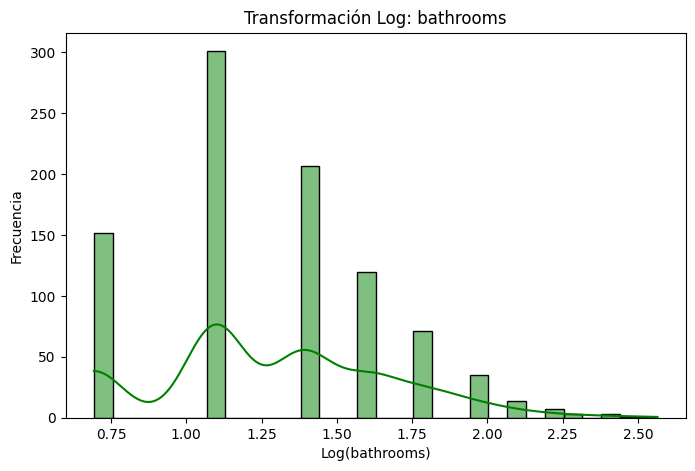

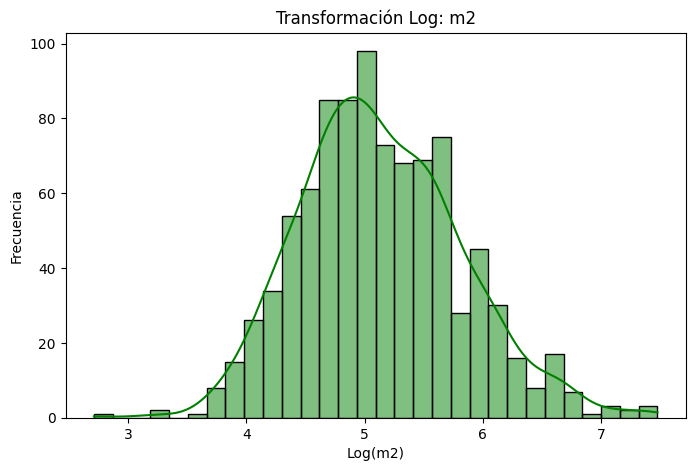


No se encontraron suficientes datos para Barrio X o Barrio Y.

Contraste de hipótesis (>= 3 baños vs 1-2 baños): p-value=2.342143441210671e-84


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carga de datos con pandas
file_path = "idealista_madrid.csv"  # Ruta del archivo
try:
    df = pd.read_csv(file_path)
except Exception as e:
    print("Error al cargar los datos:", e)
    exit()

# Renombrar columnas para mayor claridad
df.rename(columns={
    'price': 'price',
    'rooms': 'bedrooms',
    'baths': 'bathrooms',
    'sqft': 'm2'
}, inplace=True)

# Quitar ", Madrid" del campo 'address'
if 'address' in df.columns:
    df['address'] = df['address'].str.replace(", Madrid", "", regex=False)

# Convertir columnas relevantes a numérico
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'm2']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Comprobaciones básicas
print("Columnas disponibles en el DataFrame:", df.columns)

# Visualización inicial: Media, mediana, máximo y mínimo
print("Media:")
print(df[numeric_cols].mean())
print("\nMediana:")
print(df[numeric_cols].median())
print("\nMáximo y Mínimo:")
print(df[numeric_cols].agg(['max', 'min']))

# Histograma y curva de densidad para cada columna numérica
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True, bins=30, color="blue")
    plt.title(f"Histograma y Curva de Densidad: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# Cuartiles e IQR
print("\nCuartiles:")
print(df[numeric_cols].quantile([0.25, 0.5, 0.75]))
print("\nIQR:")
print(df[numeric_cols].apply(lambda x: stats.iqr(x.dropna())))

# Filtrar 20% más caro y más barato
percentile_80 = df['price'].quantile(0.8)
percentile_20 = df['price'].quantile(0.2)

top_20 = df[df['price'] >= percentile_80]
bottom_20 = df[df['price'] <= percentile_20]

# Moda de address
print("\nModa de address:")
print(df['address'].mode())

# Varianza y desviación estándar
print("\nVarianza y Desviación Estándar:")
print(df[numeric_cols].var())
print(df[numeric_cols].std())

# Outliers: Tukey y Z-Score con visualización
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.axvline(lower_bound, color='red', linestyle='--', label='Límite inferior')
    plt.axvline(upper_bound, color='blue', linestyle='--', label='Límite superior')
    plt.title(f"Detección de Outliers: {col}")
    plt.legend()
    plt.show()

# Matriz de correlación
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# Estandarización
df_standardized = df[numeric_cols].apply(lambda x: (x - x.mean()) / x.std())
print("\nDatos estandarizados (Primeras filas):")
print(df_standardized.head())

# Asimetría y curtosis
for col in numeric_cols:
    skewness = stats.skew(df[col].dropna())
    kurtosis = stats.kurtosis(df[col].dropna())
    print(f"Asimetría ({col}): {skewness}")
    print(f"Curtosis ({col}): {kurtosis}")

# Transformaciones: Log para reducir asimetría (opcional)
for col in numeric_cols:
    transformed_col = np.log1p(df[col].dropna())
    plt.figure(figsize=(8, 5))
    sns.histplot(transformed_col, kde=True, bins=30, color="green")
    plt.title(f"Transformación Log: {col}")
    plt.xlabel(f"Log({col})")
    plt.ylabel("Frecuencia")
    plt.show()

# Contraste de hipótesis
# Barrio X vs Barrio Y
barrio_x = df[df['address'] == "Nombre Barrio X"]['price']
barrio_y = df[df['address'] == "Nombre Barrio Y"]['price']

if not barrio_x.empty and not barrio_y.empty:
    stat, p_value = stats.ttest_ind(barrio_x, barrio_y, nan_policy='omit')
    print(f"\nContraste de hipótesis (Barrio X vs Barrio Y): p-value={p_value}")
else:
    print("\nNo se encontraron suficientes datos para Barrio X o Barrio Y.")

# >= 3 baños vs 1-2 baños
baths_3plus = df[df['bathrooms'] >= 3]['price']
baths_1_2 = df[(df['bathrooms'] == 1) | (df['bathrooms'] == 2)]['price']

stat, p_value = stats.ttest_ind(baths_3plus, baths_1_2, nan_policy='omit')
print(f"\nContraste de hipótesis (>= 3 baños vs 1-2 baños): p-value={p_value}")
